# 04 · Elasticity: how much volume leaves, and where it goes

The simulator needs two answers before it can price anything. When a merchant's cost of taking
cards rises, **how likely is it to stop accepting them**? And when it does, **which merchants
pick up the spend** its customers still want to put on a card?

| Question | Modules | How it is answered |
|---|---|---|
| How much leaves | `merchant_acceptance`, `calibration` | A logistic curve on relative burden, solved against two anchor figures |
| Where it goes | `link_prediction`, `scorers`, `gnn` | A ladder of rankings, from random to GraphSAGE, scored on links made in held-out months |

The two halves differ in kind. The first is an **assumption**: the synthetic data contains no
merchant that ever stopped accepting cards, so there is nothing to estimate. The second is a
**measurement**: the held-out months contain real links that no method saw.

> **Synthetic data.** The generator planted the clienteles the graph is trying to recover, and
> the curve's anchors are figures of our own. This notebook shows the framework working, not how
> Colombian merchants behave. Run `python -m ips.tasks elasticity` first: the notebook reads its
> artifacts instead of retraining the network.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.ticker import FuncFormatter, MaxNLocator, PercentFormatter

from ips.elasticity.link_prediction import (
    GRAPHSAGE,
    GROUP_POPULARITY,
    LADDER,
    POPULARITY,
    RANDOM,
    SVD,
    verdict,
)
from ips.elasticity.merchant_acceptance import sigmoid
from ips.elasticity.params import group_sensitivity
from ips.elasticity.pipeline import ARTIFACTS
from ips.utils.config import load_config
from ips.utils.io import artifacts_dir, read_table

pl.Config.set_thousands_separator(",")
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(190)
pl.Config.set_tbl_cols(14)
pl.Config.set_fmt_str_lengths(90)
start = time.perf_counter()
cfg = load_config()

base = artifacts_dir(cfg)
missing = [
    str(base / relative) for relative in ARTIFACTS.values() if not (base / relative).exists()
]
if missing:
    raise FileNotFoundError(
        "Run `python -m ips.tasks elasticity` first. Missing: " + ", ".join(missing)
    )
artifact = {name: pl.read_parquet(base / relative) for name, relative in ARTIFACTS.items()}
merchants = read_table("dim_merchant").select(
    pl.col("merchant_id").cast(pl.Int64), pl.col("mcc_group").cast(pl.Utf8)
)
{name: frame.height for name, frame in artifact.items()}

{'curve': 1,
 'curve_groups': 12,
 'acceptance': 28438,
 'response': 28438,
 'cardholder': 3,
 'comparison': 5,
 'gaps': 3,
 'substitutes': 295970,
 'redistribution': 29204,
 'losses': 400}

Chart style: the dataviz reference palette, as in notebooks 01 to 03. Categorical colours
in a fixed order, one blue ramp for magnitude, and the accent reserved for whichever method or
group the chart is about.

In [2]:
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # categorical slots 1-4, fixed order
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.axisbelow": True,
        "axes.titlelocation": "left",
        "axes.titlepad": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "xtick.color": AXIS,
        "ytick.color": AXIS,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "legend.frameon": False,
        "legend.labelcolor": INK_2,
        "lines.linewidth": 2,
        "lines.solid_capstyle": "round",
    }
)
METHOD_LABEL = {
    RANDOM: "Random",
    POPULARITY: "Global popularity",
    GROUP_POPULARITY: "Popularity in the cardholder's categories",
    SVD: "Graph embedding (PPMI + SVD)",
    GRAPHSAGE: "GraphSAGE (PyTorch Geometric)",
}
assert set(METHOD_LABEL) == set(LADDER)
POINTS = FuncFormatter(lambda value, _pos: f"{value * 100:.1f} pp")


def compact(value, _pos=None):
    """Three significant digits: 1,234 -> 1.23k; 5,600,000 -> 5.60M."""
    for threshold, suffix in ((1e12, "T"), (1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(value) >= threshold:
            return f"{value / threshold:#.3g}".rstrip(".") + suffix
    return f"{value:,.0f}"


def pretty(name):
    return str(name).replace("_", " ").capitalize()

## 1 · The acceptance curve is an assumption with two anchors

With no abandonment in the data, the curve cannot be fitted. What can be done honestly is to
**choose its parameters so it reproduces two figures** over the population as it really is —
its real distribution of relative burden, channel mix and ticket size:

1. the share of merchants that drop the card in a year fixes the **levels**;
2. the acceptance lost when every MDR rises by 10 % fixes the **slope**.

Each MCC group gets its own intercept and all groups share one slope. With a single intercept
for everyone, the slope the second anchor demands made the curve a threshold: most groups sat at
the probability floor and paid no acceptance cost for a higher MDR. The group levels are not free
either. Each scales with the group's median relative burden, normalised so the population still
sits on the first anchor — a sector that hands over twice the margin abandons twice as often.

Both figures, and that proportionality, are assumptions of our own, marked [P] in
`docs/assumptions.md`. The machinery does not change when a published source replaces them: edit
`config/elasticity.yaml` and rerun.

In [3]:
acceptance_cfg = cfg.elasticity.acceptance
curve = artifact["curve"].row(0, named=True)
shock = acceptance_cfg.semi_elasticity_shock
print(f"shared slope beta = {curve['beta']:.4f}")
pl.DataFrame(
    {
        "moment": ["Annual abandonment rate", f"Acceptance lost when every MDR rises {shock:.0%}"],
        "anchor": [curve["target_abandonment"], curve["target_semi_elasticity"]],
        "achieved": [curve["achieved_abandonment"], curve["achieved_semi_elasticity"]],
    }
).with_columns((pl.col("achieved") - pl.col("anchor")).alias("gap"))

shared slope beta = 12.5273


moment,anchor,achieved,gap
str,f64,f64,f64
"""Annual abandonment rate""",0.035,0.035,0.0
"""Acceptance lost when every MDR rises 10%""",0.018,0.018,0.0


Each group's level and the intercept that delivers it, next to the group's median
relative burden. The levels rise with burden by construction; what the calibration adds is the
intercept that puts each group exactly on its level once the shared slope is fixed.

In [4]:
groups_curve = (
    artifact["curve_groups"]
    .join(
        artifact["acceptance"]
        .group_by(pl.col("mcc_group").cast(pl.Utf8))
        .agg(
            pl.len().alias("merchants"), pl.col("relative_burden").median().alias("median_burden")
        ),
        on="mcc_group",
        how="inner",
    )
    .sort("median_burden")
)
groups_curve.select(
    "mcc_group", "merchants", "median_burden", "target_level", "achieved_level", "alpha"
)

mcc_group,merchants,median_burden,target_level,achieved_level,alpha
str,u32,f64,f64,f64,f64
"""education""",846,0.089938,0.01058,0.01058,-5.265989
"""digital""","1,486",0.127789,0.015033,0.015033,-5.66982
"""utilities_telecom""",584,0.164475,0.019349,0.019349,-5.976552
"""health""","2,313",0.182738,0.021497,0.021497,-5.597416
"""retail""","7,410",0.18355,0.021593,0.021593,-6.560205
"""entertainment""","1,399",0.213672,0.025137,0.025137,-7.168142
"""home_electronics""","1,884",0.266175,0.031313,0.031313,-7.46583
"""restaurants""","2,920",0.268002,0.031528,0.031528,-8.50906
"""transport""","1,431",0.295526,0.034766,0.034766,-10.041119


The curve for four MCC groups, from the least to the most price-sensitive. Each line is
the pure curve — its group's intercept, the shared slope — of a card-present merchant on blended
pricing with no instant-payment pressure, drawn only across the burden its own merchants occupy
(their 1st to 99th percentile): past that range a group's curve is an extrapolation no merchant of
the group lives in. Real merchants sit above their line by whatever their modifiers add. The
lower panel is where the whole population sits.

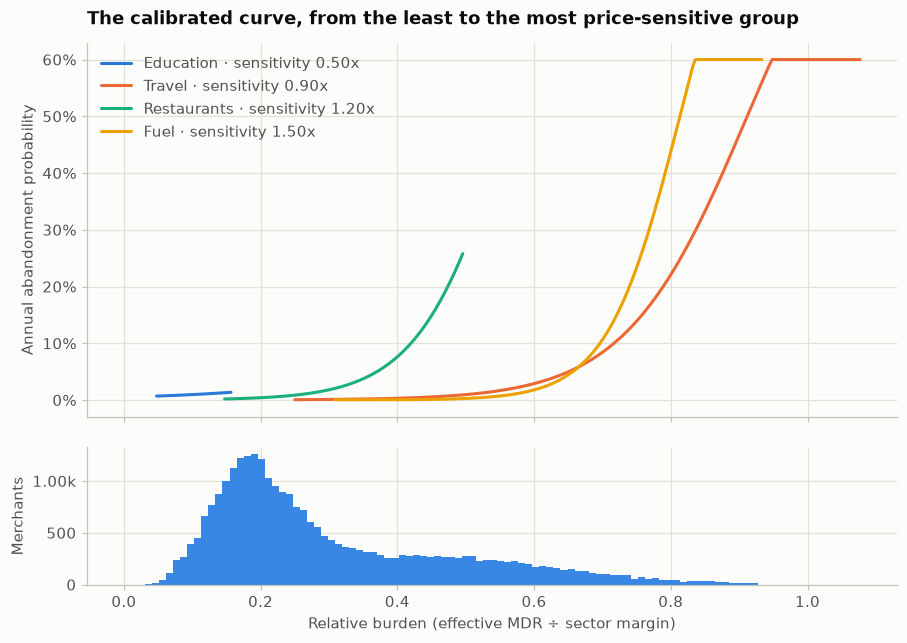

group,group_quantile,relative_burden,p_abandonment
str,str,f64,f64
"""Education""","""p25""",0.075,0.0082
"""Education""","""p50""",0.09,0.009
"""Education""","""p90""",0.122,0.011
"""Education""","""p99""",0.157,0.0136
"""Travel""","""p25""",0.395,0.0029
"""Travel""","""p50""",0.483,0.0079
"""Travel""","""p90""",0.722,0.1051
"""Travel""","""p99""",1.077,0.6
"""Restaurants""","""p25""",0.225,0.0059


In [5]:
sensitivity = group_sensitivity(cfg)
ordered = sorted(sensitivity, key=sensitivity.__getitem__)
picks = [ordered[0], ordered[len(ordered) // 3], ordered[2 * len(ordered) // 3], ordered[-1]]
acceptance = artifact["acceptance"].with_columns(pl.col("mcc_group").cast(pl.Utf8))
burden = acceptance["relative_burden"].to_numpy()
grid = np.linspace(0.0, float(np.quantile(burden, 0.995)), 400)
low, high = acceptance_cfg.min_probability, acceptance_cfg.max_probability


intercepts = dict(artifact["curve_groups"].select("mcc_group", "alpha").iter_rows())


def pure_curve(group, values):
    logit = intercepts[group] + curve["beta"] * sensitivity[group] * np.asarray(values)
    return np.clip(sigmoid(logit), low, high)


fig, (top, bottom) = plt.subplots(
    2, 1, figsize=(9.5, 6.4), sharex=True, gridspec_kw={"height_ratios": [3, 1.1], "hspace": 0.12}
)
spans = {}
for group in picks:
    own = acceptance.filter(pl.col("mcc_group") == group)["relative_burden"].to_numpy()
    spans[group] = np.linspace(np.quantile(own, 0.01), np.quantile(own, 0.99), 200)
for colour, group in zip(SERIES, picks, strict=True):
    top.plot(
        spans[group],
        pure_curve(group, spans[group]),
        color=colour,
        label=f"{pretty(group)} · sensitivity {sensitivity[group]:.2f}x",
    )
top.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
top.set_ylabel("Annual abandonment probability")
top.set_title("The calibrated curve, from the least to the most price-sensitive group")
top.legend(loc="upper left")
floor = [pretty(g) for g in picks if pure_curve(g, spans[g]).max() <= low]
if floor:
    top.annotate(
        f"{' and '.join(floor)}: at the {low:.2%} floor across the burden its merchants occupy",
        xy=(grid[len(grid) // 3], low),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        color=INK_2,
        fontsize=9,
    )
bottom.hist(burden, bins=90, range=(0.0, grid[-1]), color=BLUES[3])
bottom.set_ylabel("Merchants")
bottom.set_xlabel("Relative burden (effective MDR ÷ sector margin)")
bottom.yaxis.set_major_formatter(compact)
plt.show()

quantiles = (0.25, 0.50, 0.90, 0.99)
rows = []
for group in picks:
    own = acceptance.filter(pl.col("mcc_group") == group)["relative_burden"].to_numpy()
    for q in quantiles:
        burden_at = float(np.quantile(own, q))
        rows.append(
            {
                "group": pretty(group),
                "group_quantile": f"p{round(q * 100)}",
                "relative_burden": round(burden_at, 3),
                "p_abandonment": round(float(pure_curve(group, [burden_at])[0]), 4),
            }
        )
pl.DataFrame(rows)

## 2 · Which merchants the curve puts at risk

Two readings by MCC group, both weighted by volume. On the left, the probability of dropping
the card at today's prices — each group near the level its burden earned it. On the right, what
a 10 % rise in every MDR adds to it: the slope the second anchor fixed, spread across groups by
their levels, their sensitivity and where their merchants sit on the burden axis. Volume at risk
is measured on the 24-month window.

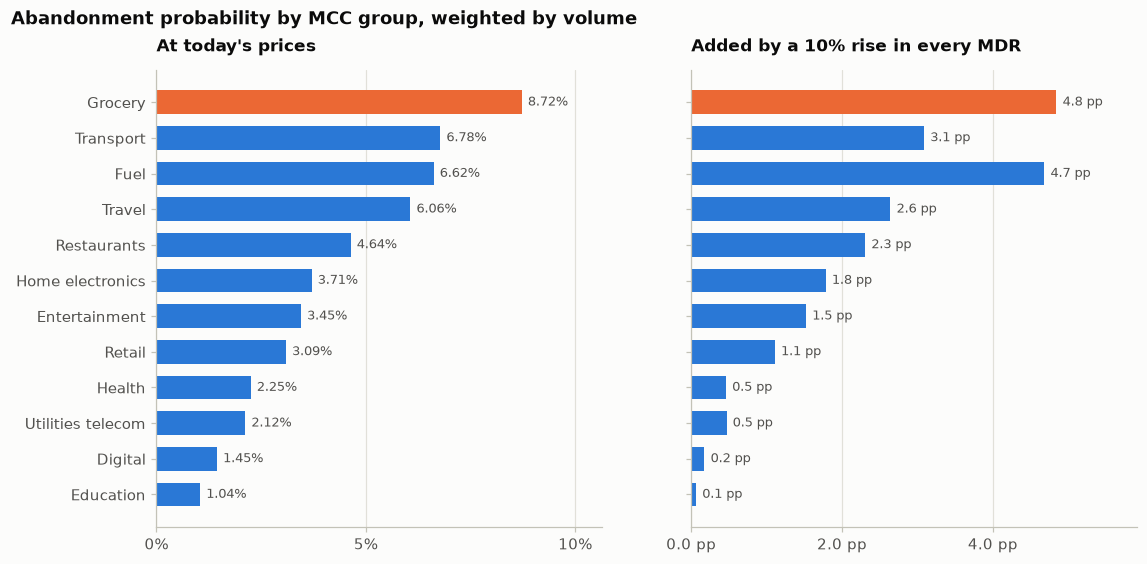

mcc_group,merchants,median_burden,p_abandonment,p_abandonment_delta,gdv_cop,gdv_at_risk_cop
str,u32,f64,f64,f64,f64,f64
"""education""",846,0.089938,0.010434,0.000649,"156,937,913,422.0","1,637,562,862.968367"
"""digital""","1,486",0.127789,0.01446,0.001759,"53,052,479,489.0","767,136,742.647539"
"""utilities_telecom""",584,0.164475,0.021206,0.004687,"34,511,096,021.0","731,833,608.09202"
"""health""","2,313",0.182738,0.022512,0.004618,"49,910,443,922.0","1,123,605,394.415329"
"""retail""","7,410",0.18355,0.03091,0.011102,"122,671,523,360.0","3,791,835,500.492904"
"""entertainment""","1,399",0.213672,0.034502,0.015238,"18,431,105,708.0","635,906,338.94943"
"""home_electronics""","1,884",0.266175,0.037058,0.017846,"182,920,164,455.0","6,778,616,602.16854"
"""restaurants""","2,920",0.268002,0.046379,0.023072,"52,965,142,147.0","2,456,477,052.98923"
"""travel""","1,052",0.483488,0.060632,0.026419,"229,381,424,658.0","13,907,818,589.029196"


In [6]:
response = artifact["response"].join(
    acceptance.select("merchant_id", "mcc_group"), on="merchant_id", how="inner"
)


def volume_weighted(column):
    return ((pl.col(column) * pl.col("gdv_cop")).sum() / pl.col("gdv_cop").sum()).alias(column)


by_group = (
    acceptance.group_by("mcc_group")
    .agg(
        pl.len().alias("merchants"),
        pl.col("relative_burden").median().alias("median_burden"),
        volume_weighted("p_abandonment"),
        pl.col("gdv_cop").sum(),
        pl.col("gdv_at_risk_cop").sum(),
    )
    .join(
        response.group_by("mcc_group").agg(volume_weighted("p_abandonment_delta")),
        on="mcc_group",
        how="inner",
    )
    .sort("p_abandonment")
)
positions = np.arange(by_group.height)
fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 5.4), sharey=True)
panels = (
    (left, "p_abandonment", "At today's prices", PercentFormatter(1.0, decimals=0), "{:.2%}"),
    (right, "p_abandonment_delta", f"Added by a {shock:.0%} rise in every MDR", POINTS, None),
)
for axis, column, title, formatter, label in panels:
    values = by_group[column].to_numpy()
    colours = [SERIES[0]] * len(values)
    colours[int(np.argmax(values))] = SERIES[1]
    axis.barh(positions, values, color=colours, height=0.66)
    axis.xaxis.set_major_formatter(formatter)
    axis.xaxis.set_major_locator(MaxNLocator(nbins=4, steps=[1, 2, 5, 10]))
    axis.set_title(title, fontsize=11)
    axis.grid(axis="y", visible=False)
    for y, value in zip(positions, values, strict=True):
        text = label.format(value) if label else f"{value * 100:.1f} pp"
        axis.annotate(
            text,
            xy=(value, y),
            xytext=(4, 0),
            textcoords="offset points",
            va="center",
            fontsize=8.5,
            color=INK_2,
        )
    axis.set_xlim(0, values.max() * 1.22)
left.set_yticks(positions, [pretty(g) for g in by_group["mcc_group"]])
fig.suptitle(
    "Abandonment probability by MCC group, weighted by volume",
    x=0.01,
    ha="left",
    fontweight="bold",
    color=INK,
)
plt.show()
by_group.select(
    "mcc_group",
    "merchants",
    "median_burden",
    "p_abandonment",
    "p_abandonment_delta",
    "gdv_cop",
    "gdv_at_risk_cop",
)

The cardholder side of the loop, for the simulator to close later: what a one-point cut
in the rewards rate does to card spend, by spend segment. High spenders react most because they
are the ones who optimise rewards; the response is bounded because some spend does not follow
incentives. These semi-elasticities are assumptions of our own as well.

In [7]:
artifact["cardholder"].with_columns((pl.col("spend_multiplier") - 1.0).alias("spend_change"))

spend_segment,rewards_semi_elasticity,rewards_rate_change,spend_multiplier,spend_change
str,f64,f64,f64,f64
"""low""",0.4,-0.01,0.996008,-0.003992
"""mid""",0.9,-0.01,0.99104,-0.00896
"""high""",1.6,-0.01,0.984127,-0.015873


## 3 · Where the volume goes: the link-prediction ladder

Feature 4 asked the graph what a merchant **pays**, and it had nothing to add. This asks what
the graph was built for: when a cardholder starts buying somewhere new, **where**?

- **Time separates training from evaluation.** The last three months are held out; a positive is
  a cardholder-merchant link that appears there for the first time. Repeat purchases don't count.
- **Every method ranks the same candidates for the same cardholders**, with each cardholder's own
  history masked out.
- **The rung to beat is popularity inside the cardholder's own categories.** It uses no graph,
  and a representation that cannot beat it is only popularity in disguise.

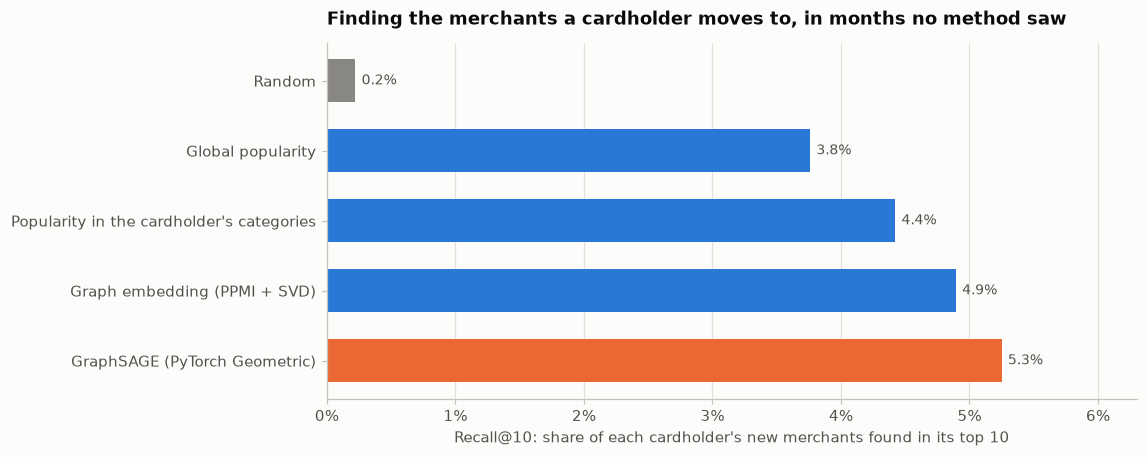

Substitutes are built from: GraphSAGE (PyTorch Geometric)


method,recall_at_k,hit_rate_at_k,mrr,coverage,cardholders,positives
str,f64,f64,f64,f64,i64,i64
"""random""",0.002226,0.006,0.002526,0.999,"2,000","5,047"
"""popularity""",0.037608,0.09,0.030256,0.005667,"2,000","5,047"
"""group_popularity""",0.044232,0.1005,0.040561,0.045667,"2,000","5,047"
"""graph_svd""",0.048952,0.104,0.035946,0.745,"2,000","5,047"
"""graphsage""",0.052513,0.1175,0.048028,0.077667,"2,000","5,047"


In [8]:
comparison = artifact["comparison"]
source = comparison["substitute_source"][0]
comparison = comparison.drop("substitute_source")
k = cfg.elasticity.link_prediction.top_k
recall = comparison["recall_at_k"].to_numpy()
winner = int(np.argmax(recall))
positions = np.arange(comparison.height)
fig, axis = plt.subplots(figsize=(9.5, 4.2))
colours = [MUTED if method == RANDOM else SERIES[0] for method in comparison["method"]]
colours[winner] = SERIES[1]
axis.barh(positions, recall, color=colours, height=0.62)
axis.set_yticks(positions, [METHOD_LABEL[method] for method in comparison["method"]])
axis.invert_yaxis()
axis.grid(axis="y", visible=False)
axis.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
axis.set_xlim(0, recall.max() * 1.2)
axis.set_xlabel(f"Recall@{k}: share of each cardholder's new merchants found in its top {k}")
axis.set_title("Finding the merchants a cardholder moves to, in months no method saw")
for y, value in zip(positions, recall, strict=True):
    axis.annotate(
        f"{value:.1%}",
        xy=(value, y),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        color=INK_2,
    )
plt.show()
print(f"Substitutes are built from: {METHOD_LABEL[source]}")
comparison

A lead is only a lead if it survives the noise of which cardholders happened to be
evaluated. Each gap below comes with a paired bootstrap interval over those cardholders: a gap
whose interval crosses zero is reported as indistinguishable, not as a win.

In [9]:
gaps = artifact["gaps"]
for baseline, challenger in gaps.select("baseline", "challenger").iter_rows():
    print(verdict(gaps, baseline, challenger))
gaps

The graph_svd ranking cannot be told apart from group_popularity at finding the merchants a cardholder moves to: recall@k 0.049 vs 0.044 (gap +0.005, 95% CI -0.006 to +0.015).
The graphsage ranking beats group_popularity at finding the merchants a cardholder moves to: recall@k 0.053 vs 0.044 (gap +0.008, 95% CI +0.002 to +0.015).
The graphsage ranking cannot be told apart from graph_svd at finding the merchants a cardholder moves to: recall@k 0.053 vs 0.049 (gap +0.004, 95% CI -0.007 to +0.015).


baseline,challenger,recall_baseline,recall_challenger,gap,ci_low,ci_high,confidence_level
str,str,f64,f64,f64,f64,f64,f64
"""group_popularity""","""graph_svd""",0.044232,0.048952,0.004719,-0.00569,0.015351,0.95
"""group_popularity""","""graphsage""",0.044232,0.052513,0.00828,0.002221,0.014949,0.95
"""graph_svd""","""graphsage""",0.048952,0.052513,0.003561,-0.007459,0.014733,0.95


GraphSAGE's training edges are split three ways — the graph it passes messages over, the
links it is fitted on, and a validation set. The vectors it keeps are those of the epoch with the
best validation loss, and training ends either when that loss goes a while without improving or
when the epoch budget runs out; the title says which happened. The held-out months play no part
in either choice.

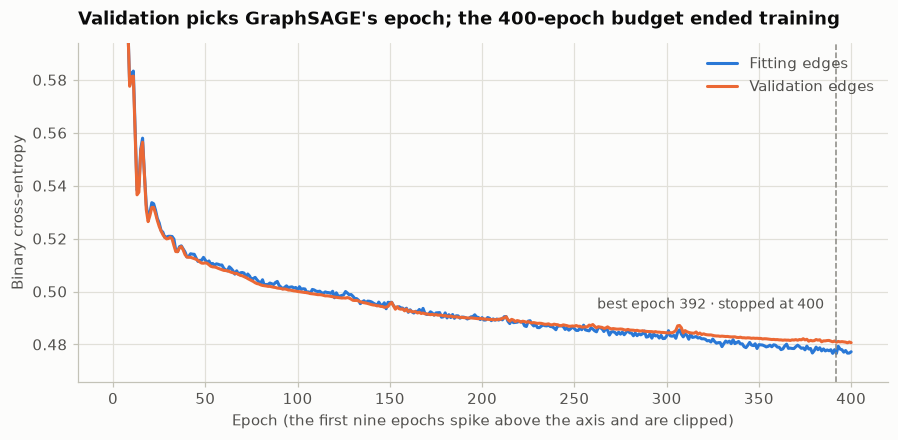

epoch,loss,validation_loss,is_best
i64,f64,f64,bool
392,0.476605,0.480854,true
400,0.477233,0.480659,false


In [10]:
losses = artifact["losses"]
best = losses.filter(pl.col("is_best")).row(0, named=True)
fig, axis = plt.subplots(figsize=(9.5, 4.0))
axis.plot(losses["epoch"], losses["loss"], color=SERIES[0], label="Fitting edges")
axis.plot(losses["epoch"], losses["validation_loss"], color=SERIES[1], label="Validation edges")
axis.axvline(best["epoch"], color=MUTED, linestyle="--", linewidth=1)
axis.annotate(
    f"best epoch {best['epoch']} · stopped at {losses.height}",
    xy=(best["epoch"], best["validation_loss"]),
    xytext=(-8, 22),
    textcoords="offset points",
    ha="right",
    color=INK_2,
    fontsize=9,
)
# The first epochs spike far above the rest and flatten the tail, where stopping is decided.
settled = losses.filter(pl.col("epoch") >= 10)
upper = max(settled["loss"].max(), settled["validation_loss"].max())
lower = min(settled["loss"].min(), settled["validation_loss"].min())
axis.set_ylim(lower - 0.1 * (upper - lower), upper + 0.1 * (upper - lower))
axis.set_xlabel("Epoch (the first nine epochs spike above the axis and are clipped)")
axis.set_ylabel("Binary cross-entropy")
max_epochs = cfg.elasticity.link_prediction.gnn.max_epochs
ended_by = "early stopping" if losses.height < max_epochs else f"the {max_epochs}-epoch budget"
axis.set_title(f"Validation picks GraphSAGE's epoch; {ended_by} ended training")
axis.legend(loc="upper right")
plt.show()
losses.filter(pl.col("is_best") | (pl.col("epoch") == losses.height))

## 4 · Substitutes and the volume they receive

When a merchant drops the card, its expected lost volume is spread over its ten nearest
merchants in the winning representation, after a share leaks off the card rails. Substitutes are
**not** restricted to the merchant's own MCC group: if the graph is worth its place it should
find substitutes the category does not see, and that is measured here rather than imposed. The
orange dot is what a random draw of substitutes would give.

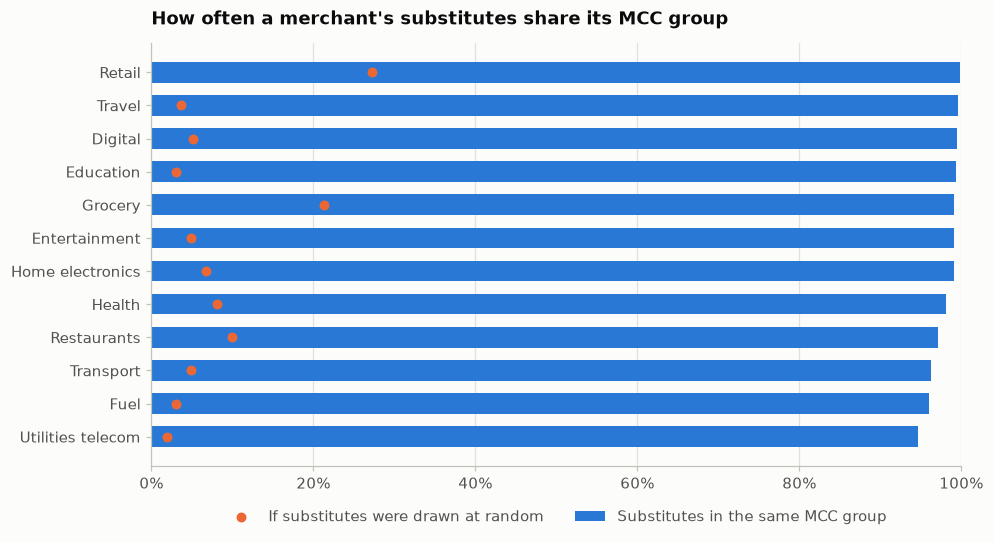

Across all merchants, 99% of substitutes share the MCC group; the MCC benchmark would force 100%.


mcc_group,same_group,pairs,chance
str,f64,u32,f64
"""utilities_telecom""",0.946928,"5,860",0.019799
"""fuel""",0.960706,"9,060",0.030611
"""transport""",0.962945,"14,330",0.048417
"""restaurants""",0.971666,"29,470",0.099571
"""health""",0.980811,"23,920",0.080819
"""home_electronics""",0.990578,"20,060",0.067777
"""entertainment""",0.990928,"14,550",0.04916
"""grocery""",0.991203,"63,200",0.213535
"""education""",0.99343,"8,980",0.030341


In [11]:
substitutes = (
    artifact["substitutes"]
    .with_columns(pl.col("merchant_id", "substitute_id").cast(pl.Int64))
    .join(merchants, on="merchant_id", how="inner")
    .join(
        merchants.rename({"merchant_id": "substitute_id", "mcc_group": "substitute_group"}),
        on="substitute_id",
        how="inner",
    )
)
universe = merchants.join(substitutes.select("merchant_id").unique(), on="merchant_id", how="semi")
chance = universe.group_by("mcc_group").agg((pl.len() / universe.height).alias("chance"))
same = (
    substitutes.group_by("mcc_group")
    .agg(
        (pl.col("mcc_group") == pl.col("substitute_group")).mean().alias("same_group"),
        pl.len().alias("pairs"),
    )
    .join(chance, on="mcc_group", how="inner")
    .sort("same_group")
)
positions = np.arange(same.height)
fig, axis = plt.subplots(figsize=(9.5, 5.0))
axis.barh(
    positions,
    same["same_group"],
    color=SERIES[0],
    height=0.62,
    label="Substitutes in the same MCC group",
)
axis.scatter(
    same["chance"],
    positions,
    color=SERIES[1],
    zorder=3,
    s=30,
    label="If substitutes were drawn at random",
)
axis.set_yticks(positions, [pretty(g) for g in same["mcc_group"]])
axis.grid(axis="y", visible=False)
axis.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
axis.set_xlim(0, 1)
axis.set_title("How often a merchant's substitutes share its MCC group")
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=2)
plt.show()
overall = float((substitutes["mcc_group"] == substitutes["substitute_group"]).mean())
print(
    f"Across all merchants, {overall:.0%} of substitutes share the MCC group; "
    "the MCC benchmark would force 100%."
)
same

The redistribution keeps its books: the volume moved to substitutes plus the volume that
leaves the card rails equals the volume lost, the same kind of identity the P&L keeps for fees.
Merchants with no substitute leak their whole volume.

In [12]:
redistribution = artifact["redistribution"]
lost = float(acceptance["gdv_at_risk_cop"].sum())
moved = float(redistribution["gdv_moved_cop"].sum())
leaked = float(redistribution["gdv_leaked_cop"][0])
pl.DataFrame(
    {
        "line": [
            "Expected volume lost",
            "Moved to substitutes",
            "Left the card rails",
            "Moved + left - lost",
        ],
        "cop": [lost, moved, leaked, moved + leaked - lost],
        "share_of_lost": [1.0, moved / lost, leaked / lost, (moved + leaked - lost) / lost],
    }
)

line,cop,share_of_lost
str,f64,f64
"""Expected volume lost""","39,779,099,091.660049",1.0
"""Moved to substitutes""","25,843,260,405.624676",0.649669
"""Left the card rails""","13,935,838,686.035372",0.350331
"""Moved + left - lost""",0.0,0.0


## 5 · Limits

- **The curve is not evidence.** Both anchors, and the rule that group levels scale with burden,
  are assumptions of our own until a published source replaces them, and the curve has never
  seen a merchant drop the card. What this notebook shows is that the calibration lands where it
  is told to, over the population as it is.
- **The ladder measures a structure the generator planted.** Whichever rung wins, it wins at
  recovering clienteles that exist in these data; that says nothing about how Colombian
  cardholders actually shop.
- **GraphSAGE's budget is capped for a laptop CPU.** When the epoch budget ends training before
  early stopping does, a longer run can only help GraphSAGE; its standing on the ladder is a
  floor, not a ceiling.
- **Substitutes are merchant-to-merchant.** The rankings are learned cardholder-to-merchant;
  spreading a lost merchant's volume by vector similarity approximates spreading each customer's
  spend by that customer's own ranking.
- **Volumes are expected values over the 24-month window.** An annual probability times the
  window's volume is a scale, not a forecast; the simulator (Feature 6) turns it into scenarios
  on its own horizon.

In [13]:
print(f"Notebook runtime: {time.perf_counter() - start:.1f} s")

Notebook runtime: 1.4 s
